In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import accuracy_score
from utils import utils_ml 

from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.feature_selection import VarianceThreshold
from utils import utils_ml
import glob

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.base import clone
from sklearn.multioutput import ClassifierChain
import numpy as np
import joblib
import os
from catboost import CatBoostClassifier

In [2]:
# Automatically find the matching file
input_files = glob.glob('training_features*.npy')
if not input_files:
    raise FileNotFoundError("No features_filtered*.npy file found in current directory")
input_path = input_files[0]

# Load memory-mapped array
print(f"Loading features from {input_path}")
X_arr = np.load(input_path, mmap_mode='r').astype(np.float32)[::100]

# Class mapping dictionary
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],  # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}


# File paths
file_prefix = "rawFeatures/P"
file_suffix = "_intensity.pkl"
num_files = 35

# Load labels
print("Loading labels...")
y_arr_classification = np.array([
    np.tile(i, 10000) 
    for i in np.arange(num_files)
]).flatten()[::100]

def convert_labels(old_labels, class_to_poles):
    """
    Convert class labels to pole representation.
    
    Parameters:
        old_labels (np.ndarray): Array of class labels.
        class_to_poles (dict): Mapping from class labels to pole representations.
        
    Returns:
        np.ndarray: A 2D array with pole representations.
    """
    # Initialize a new array with shape (length of old labels, 3)
    new_labels = np.zeros((len(old_labels), 3), dtype=int)
    
    # Populate the new label array based on the mapping
    for i, label in enumerate(old_labels):
        new_labels[i] = class_to_poles[label]
    
    return new_labels

y_arr_regression = convert_labels(y_arr_classification, class_to_poles) * 1.0

class_to_poles_arr = np.array([class_to_poles[i] for i in range(num_files)])
y_bt = class_to_poles_arr[y_arr_classification][:, 0]
y_bb = class_to_poles_arr[y_arr_classification][:, 1]
y_tb = class_to_poles_arr[y_arr_classification][:, 2]

Loading features from training_features_128_T11BG.npy
Loading labels...


In [3]:
class Ensemble(object):
    
    def __init__(self, esize=10, iterations=1000, seed=42):
        
        
        self.seed = seed
        self.esize=esize
        self.iterations=iterations
        self.ensemble = []
        for e in range(self.esize):
            model = CatBoostClassifier(iterations=self.iterations,
                           loss_function='MultiClass',
                           verbose=100,
                           bootstrap_type='No',
                           posterior_sampling=True,
                           random_seed=self.seed+e,
                           early_stopping_rounds=10)
            self.ensemble.append(model)
        
    def fit(self, X,y, eval_set = None):
        
        for m in self.ensemble:
            m.fit(X, y, use_best_model=True, early_stopping_rounds=10, eval_set=eval_set)
            print("best iter ", m.get_best_iteration())
            print("best score ", m.get_best_score())
            
    
    def predict(self,x):
        probs = []
        
        for m in self.ensemble:
            prob = m.predict_proba(x)
            probs.append(prob)
        probs = np.stack(probs)
        return probs
    
    def save(self, base_filepath):
        """Save the entire ensemble."""
        # Save ensemble metadata
        metadata = {
            'seed': self.seed,
            'esize': self.esize,
            'iterations': self.iterations,
        }
        joblib.dump(metadata, f"{base_filepath}_metadata.pkl")
        
        # Save each model in the ensemble
        os.makedirs(f"{base_filepath}_models", exist_ok=True)
        for idx, model in enumerate(self.ensemble):
            model.save_model(f"{base_filepath}_models/model_{idx}.cbm")
    
    def load(self, base_filepath):
        """Load the entire ensemble."""
        # Load metadata
        metadata = joblib.load(f"{base_filepath}_metadata.pkl")
        self.seed = metadata['seed']
        self.esize = metadata['esize']
        self.iterations = metadata['iterations']
       
        
        # Load each model
        self.ensemble = []
        for idx in range(self.esize):
            model = CatBoostClassifier(
                iterations=self.iterations,
                loss_function='MultiClass',
                verbose=100,
                bootstrap_type='No',
                posterior_sampling=True,
                random_seed=self.seed+idx,
                early_stopping_rounds=10
            )
            model.load_model(f"{base_filepath}_models/model_{idx}.cbm")
            self.ensemble.append(model)


def kl_divergence(probs1, probs2, epsilon=1e-10):
    return np.sum(probs1 * (np.log(probs1 + epsilon) - np.log(probs2 + epsilon)), axis=1)

def entropy_of_expected(probs, epsilon=1e-10):
    mean_probs = np.mean(probs, axis=0)
    log_probs = -np.log(mean_probs + epsilon)
    return np.sum(mean_probs * log_probs, axis=1)

def expected_entropy(probs, epsilon=1e-10):
    log_probs = -np.log(probs + epsilon)

    return np.mean(np.sum(probs * log_probs, axis=2), axis=0)

def mutual_information(probs, epsilon):
    eoe = entropy_of_expected(probs, epsilon)
    exe = expected_entropy(probs, epsilon)
    return eoe - exe

def ensemble_uncertainties(probs, epsilon=1e-10):
    mean_probs = np.mean(probs, axis=0)
    conf = np.max(mean_probs, axis=1)

    eoe = entropy_of_expected(probs, epsilon)
    exe = expected_entropy(probs, epsilon)
    mutual_info = eoe - exe


    uncertainty = {'confidence': conf,
                   'entropy_of_expected': eoe,        # total_uncertainty !
                   'expected_entropy': exe,           # data_uncertainty !
                   'mutual_information': mutual_info, # Knowledge Uncertainty!
                  }

    return uncertainty

class EnsembleWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, esize=10, iterations=1000, seed=100):
        self.esize = esize
        self.iterations = iterations
        self.seed = seed

        self.ensemble = Ensemble(
            esize=self.esize,
            iterations=self.iterations,
            seed=self.seed
        )

    def fit(self, X, y, eval_set=None):
        if eval_set is not None:
            X_val, y_val = eval_set
            eval_data = [(X_val, y_val)]
        else:
            eval_data = None
        self.ensemble.fit(X, y, eval_set=eval_data)
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        probs = self.ensemble.predict(X)
        mean_probs = np.mean(probs, axis=0)
        return np.argmax(mean_probs, axis=1)

    def predict_proba(self, X):
        return np.mean(self.ensemble.predict(X), axis=0)

    def predict_with_uncertainty(self, X):
        probs = self.ensemble.predict(X)
        return ensemble_uncertainties(probs), probs
    
    def save_model(self, filepath):
        """Save the ensemble wrapper model."""
        # Save wrapper metadata
        wrapper_metadata = {
            'esize': self.esize,
            'iterations': self.iterations,
            'seed': self.seed,
            'classes_': getattr(self, 'classes_', None)
        }
        joblib.dump(wrapper_metadata, f"{filepath}_wrapper.pkl")
        
        # Save the ensemble
        self.ensemble.save(filepath)
    
    def load_model(self, filepath):
        """Load the ensemble wrapper model."""
        # Load wrapper metadata
        wrapper_metadata = joblib.load(f"{filepath}_wrapper.pkl")
        self.esize = wrapper_metadata['esize']
        self.iterations = wrapper_metadata['iterations']
        self.seed = wrapper_metadata['seed']
        if wrapper_metadata['classes_'] is not None:
            self.classes_ = wrapper_metadata['classes_']
        
        # Create and load the ensemble
        self.ensemble = Ensemble(
            esize=self.esize,
            iterations=self.iterations,
            seed=self.seed
        )
        self.ensemble.load(filepath)
        return self


class EvalClassifierChain(ClassifierChain):
    def fit(self, X, Y, eval_set=None, **fit_params):
        """Custom fit to support eval_set for each wrapped estimator."""
        X = np.asarray(X)
        Y = np.asarray(Y)

        self.order_ = self.order if self.order != 'random' else np.random.permutation(Y.shape[1])
        self.estimators_ = []

        for chain_idx, label_idx in enumerate(self.order_):
            y = Y[:, label_idx]
            if chain_idx > 0:
                X_extended = np.hstack((X, Y[:, self.order_[:chain_idx]]))
            else:
                X_extended = X

            estimator = clone(self.base_estimator)

            if eval_set is not None:
                X_val, Y_val = eval_set
                y_val = Y_val[:, label_idx]
                if chain_idx > 0:
                    X_val_extended = np.hstack((X_val, Y_val[:, self.order_[:chain_idx]]))
                else:
                    X_val_extended = X_val
                estimator.fit(X_extended, y, eval_set=(X_val_extended, y_val))
            else:
                estimator.fit(X_extended, y)

            self.estimators_.append(estimator)

        return self

    def save_chain(self, base_filepath):
        """Save the entire classifier chain."""
        # Save the chain structure using joblib
        chain_data = {
            'order_': self.order_,
            'order': self.order,
            'base_estimator': self.base_estimator
        }
        joblib.dump(chain_data, f"{base_filepath}_chain.pkl")
        
        # Save each individual estimator
        os.makedirs(f"{base_filepath}_chain_models", exist_ok=True)
        for idx, estimator in enumerate(self.estimators_):
            if hasattr(estimator, 'save_model'):
                estimator.save_model(f"{base_filepath}_chain_models/estimator_{idx}")
            else:
                joblib.dump(estimator, f"{base_filepath}_chain_models/estimator_{idx}.pkl")

    def load_chain(self, base_filepath, classes=None):
        """Load the entire classifier chain."""
        # Load chain structure
        chain_data = joblib.load(f"{base_filepath}_chain.pkl")
        self.order_ = chain_data['order_']
        self.order = chain_data['order']
        self.base_estimator = chain_data['base_estimator']
        
        # Load individual estimators
        self.estimators_ = []
        for idx in range(len(self.order_)):
            estimator = clone(self.base_estimator)
            
            if hasattr(estimator, 'load_model'):
                estimator.load_model(f"{base_filepath}_chain_models/estimator_{idx}")
                # Set classes if provided
                if classes is not None:
                    estimator.classes_ = classes
            else:
                pkl_path = f"{base_filepath}_chain_models/estimator_{idx}.pkl"
                if os.path.exists(pkl_path):
                    estimator = joblib.load(pkl_path)
            
            self.estimators_.append(estimator)
        
        return self


# Example usage
if __name__ == "__main__":
    # Create sample data
    np.random.seed(42)
   
    
    # Base model is now the ensemble
    base_model = EnsembleWrapper(esize=2, iterations=10, seed=42)  # Small values for quick testing
    
    # Classifier chain with uncertainty-aware base models
    chain = EvalClassifierChain(base_estimator=base_model, order=[0, 1, 2])
    
    # Train (using smaller subset for quick testing)
    chain.fit(X_arr, y_arr_regression, eval_set=(X_arr, y_arr_regression))
    
    # Make predictions
    predictions = chain.predict(X_arr)
    print(f"Original predictions shape: {predictions.shape}")
    
    # Save the entire chain
    chain.save_chain("test")
    
    # Load the chain
    unique_classes = np.array([0, 1, 2])
    new_chain = EvalClassifierChain(base_estimator=base_model, order=[0, 1, 2])
    new_chain.load_chain("test", classes=unique_classes)
    
    # Verify loaded model works
    loaded_predictions = new_chain.predict(X_arr)
    print(f"Loaded predictions shape: {loaded_predictions.shape}")
    print(f"Predictions match: {np.array_equal(predictions, loaded_predictions)}")
    
    # Test uncertainty predictions
    if hasattr(new_chain.estimators_[0], 'predict_with_uncertainty'):
        uncertainty, probs = new_chain.estimators_[0].predict_with_uncertainty(X_arr[:5])
        print(f"Uncertainty keys: {uncertainty.keys()}")
        print(f"Probs shape: {probs.shape}")

Learning rate set to 0.5
0:	learn: 0.7041337	test: 0.7041337	best: 0.7041337 (0)	total: 96.7ms	remaining: 871ms
9:	learn: 0.1343846	test: 0.1343846	best: 0.1343846 (9)	total: 544ms	remaining: 0us

bestTest = 0.1343845957
bestIteration = 9

best iter  9
best score  {'learn': {'MultiClass': 0.13438459571985947}, 'validation': {'MultiClass': 0.13438459571985947}}
Learning rate set to 0.5
0:	learn: 0.7790470	test: 0.7790470	best: 0.7790470 (0)	total: 49.8ms	remaining: 448ms
9:	learn: 0.1401890	test: 0.1401890	best: 0.1401890 (9)	total: 526ms	remaining: 0us

bestTest = 0.1401889974
bestIteration = 9

best iter  9
best score  {'learn': {'MultiClass': 0.14018899738038}, 'validation': {'MultiClass': 0.14018899738038}}
Learning rate set to 0.5
0:	learn: 1.0635009	test: 1.0635009	best: 1.0635009 (0)	total: 52ms	remaining: 468ms
9:	learn: 0.5049302	test: 0.5049302	best: 0.5049302 (9)	total: 490ms	remaining: 0us

bestTest = 0.5049301554
bestIteration = 9

best iter  9
best score  {'learn': {'Multi

In [4]:
i = 1
base_model = EnsembleWrapper(esize=5, iterations=1000, seed=42)

unique_classes = np.array([0, 1, 2,])
new_chain = EvalClassifierChain(base_estimator=base_model, order=[0, 1, 2])
new_chain.load_chain(f"models/catboost_model_c3ru_fold{i}", classes=np.unique(y_arr_regression))

# Verify loaded model works
y_pred = new_chain.predict(X_arr)
acc = accuracy_score(utils_ml.reconvert_labels(y_pred,class_to_poles),utils_ml.reconvert_labels(y_arr_regression,class_to_poles))


In [5]:
# Get pole1 predictions + uncertainty
pole1_uncertainty, pole1_probs = chain.estimators_[0].predict_with_uncertainty(X_arr)
pole1_preds = np.argmax(np.mean(pole1_probs, axis=0), axis=1)
X2 = np.concatenate([X_arr, pole1_preds[:, None]], axis=1)

# Get pole2 predictions + uncertainty
pole2_uncertainty, pole2_probs = chain.estimators_[1].predict_with_uncertainty(X2)
pole2_preds = np.argmax(np.mean(pole2_probs, axis=0), axis=1)
X3 = np.concatenate([X2, pole2_preds[:, None]], axis=1)

# Get pole3 predictions + uncertainty
pole3_uncertainty, pole3_probs = chain.estimators_[2].predict_with_uncertainty(X3)


In [6]:
predictions = np.stack([np.argmax(np.mean(pole1_probs, axis=0), axis=1),
np.argmax(np.mean(pole2_probs, axis=0), axis=1),
np.argmax(np.mean(pole3_probs, axis=0), axis=1),],axis=1)

# predictions_proba = np.stack([np.max(np.mean(pole1_probs, axis=0), axis=1),
# np.max(np.mean(pole2_probs, axis=0), axis=1),
# np.max(np.mean(pole3_probs, axis=0), axis=1),],axis=1)

In [7]:
expected_entropy = np.stack([pole1_uncertainty["expected_entropy"],
                             pole2_uncertainty["expected_entropy"],
                             pole3_uncertainty["expected_entropy"]],axis=-1)

mutual_information = np.stack([pole1_uncertainty["mutual_information"],
                             pole2_uncertainty["mutual_information"],
                             pole3_uncertainty["mutual_information"]],axis=-1)
confidence = np.stack([pole1_uncertainty["confidence"],
                             pole2_uncertainty["confidence"],
                             pole3_uncertainty["confidence"]],axis=-1)


In [8]:
accuracy_score(utils_ml.reconvert_labels(predictions,class_to_poles),utils_ml.reconvert_labels(y_arr_regression,class_to_poles))

0.6634285714285715

In [9]:
# p_conv =  utils_ml.reconvert_labels(predictions, class_to_poles)*1.0
# l_conv =  utils_ml.reconvert_labels(y_test, class_to_poles)*1.0

# utils_ml.plot_uncer(predictions, y_arr_regression, expected_entropy, mutual_information)

In [10]:
# 
# fig, axes = plt.subplots(3, 1, figsize=(2.3, 6), sharex=True)

# # Remove vertical spacing
# plt.subplots_adjust(hspace=0)

# for i, pos in enumerate(positions):
#     correct = predictions[:, i] == y_arr_regression[:, i]
#     entropy_correct = expected_entropy[correct, i]
#     entropy_incorrect = expected_entropy[~correct, i]
    
#     ax = axes[i]
#     ax.hist(entropy_correct, bins=20, alpha=0.7, label='Correct', color='C0')
#     ax.hist(entropy_incorrect, bins=20, alpha=0.7, label='Incorrect', color='C1')
    
#     ax.set_xlim(0, np.max(expected_entropy))
#     ax.axvline(np.mean(entropy_correct), color='C0', linestyle='dashed', linewidth=1)
#     ax.axvline(np.mean(entropy_incorrect), color='C1', linestyle='dashed', linewidth=1)
    

#     if i == 0:
#         # Add label inside plot (bottom right)
#         ax.text(0.98, 0.65, pos, transform=ax.transAxes,
#                 ha='right', va='top', fontsize='medium', bbox=dict(facecolor='none', edgecolor='none', alpha=0.7))
#     else:
#         ax.text(0.98, 0.95, pos, transform=ax.transAxes,
#                 ha='right', va='top', fontsize='medium', bbox=dict(facecolor='none', edgecolor='none', alpha=0.7))
    
#     # Only add x-axis label on bottom subplot
#     if i == 2:
#         ax.set_xlabel('Entropy $H(\\bar{p})$')
#         ax.tick_params(axis='x', labelbottom=True)
#         ax.set_xticks([0,0.5,1,1.5])

#     else:
#         # ax.set_xticklabels([])
#         pass
    
#     # Only add y-axis label on middle plot for clarity
#     if i == 1:
#         ax.set_ylabel('Count')

    

# # Add legend to the top plot
# axes[0].legend(fontsize='small', loc='upper right')
# plt.savefig("uncer_dist.pdf", dpi=300, bbox_inches='tight', pad_inches=0)
# plt.show()


/tmp/ipykernel_30816/3676646902.py:24: RuntimeWarning: invalid value encountered in scalar divide
  acc = np.sum(remaining_true == np.round(remaining_preds)) /remaining_preds.shape[0]


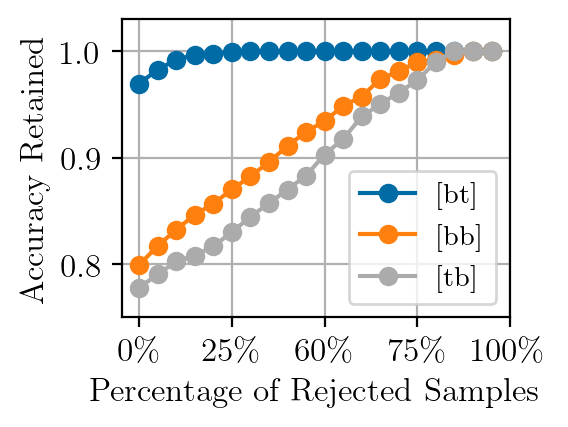

In [11]:
positions = ['[bt]', '[bb]', '[tb]']

# Sort the data by uncertainty for each target
mse_changes = []
percent_removed = []

for i in range(y_arr_regression.shape[1]):
    sorted_indices = np.argsort(expected_entropy[:, i])[::-1] 
    sorted_uncertainties = expected_entropy[sorted_indices, i]
    sorted_true = y_arr_regression[sorted_indices, i]
    sorted_preds = predictions[sorted_indices, i]

    # Calculate the MSE after removing samples with the highest uncertainty
    acc_list = []
    percent_list = []
    total_samples = len(sorted_uncertainties)

    for remove_percent in range(0, 101, 5):  # Remove in 5% increments
        num_remove = int(total_samples * (remove_percent / 100))
        remaining_true = sorted_true[num_remove:]
        remaining_preds = sorted_preds[num_remove:]

        # mse = np.mean((remaining_true - remaining_preds) ** 2)  # Calculate MSE
        acc = np.sum(remaining_true == np.round(remaining_preds)) /remaining_preds.shape[0]
        acc_list.append(acc)
        percent_list.append(remove_percent)
        

    mse_changes.append(acc_list)
    percent_removed.append(percent_list)


fig, axs = plt.subplots(1,figsize=(3, 2.3))

for i in range(y_arr_regression.shape[1]):
    axs.plot(percent_removed[i], mse_changes[i],"-o", label=positions[i])
axs.set_xlabel("Percentage of Rejected Samples")
axs.set_ylabel("Accuracy Retained")
axs.legend(fontsize='small')
axs.set_xticks([0, 25, 50, 75, 100])
axs.set_xticklabels([f"{int(p)}\%" for p in [0, 25, 60, 75,  100]])
axs.grid(True)
axs.set_ylim(0.75,1.03)
fig.tight_layout()
plt.savefig("reject.pdf", dpi=300, bbox_inches='tight', pad_inches=0)

